## Data Exploration

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid') # visual style for seaborn and matplotlib plots
pd.set_option('display.max_columns', None) # show all columns when printing

In [3]:
df = pd.read_csv('EVOreal_time_synth.csv', parse_dates=['Timestamp'])
print(f'Shape: {df.shape}') # (samples, ID + features)
print(f'Columns: {df.columns.tolist()}') # ID + features

Shape: (399500, 28)
Columns: ['ID', 'SoundClass', 'hProg', 'hVol', 'LonRel', 'LatRel', 'lowSPL', 'midSPL', 'highSPL', 'fbSPL', 'lowNf', 'midNf', 'highNf', 'fbNf', 'lowME', 'midME', 'highME', 'fbME', 'Timestamp', 'lowSNR', 'midSNR', 'highSNR', 'fbSNR', 'lowMI', 'midMI', 'highMI', 'fbMI', 'PTA4']


In [3]:
df.head()

,ID,SoundClass,hProg,hVol,LonRel,LatRel,lowSPL,midSPL,highSPL,fbSPL,lowNf,midNf,highNf,fbNf,lowME,midME,highME,fbME,Timestamp,lowSNR,midSNR,highSNR,fbSNR,lowMI,midMI,highMI,fbMI,PTA4
0,31,Speech,Medium,-1.0,-0.359245,0.024797,61.066741,52.249891,21.764549,57.267331,54.369832,30.735612,23.160576,51.031340,57.953189,60.361381,36.657727,67.197759,2018-04-20 15:24:09,6.696909,21.514279,-1.396027,6.235991,3.583357,29.625769,13.497151,16.166419,37.50
1,1,Speech,Medium,-5.0,2.806775,1.368971,41.658817,85.111911,40.298745,72.665997,13.309944,23.030578,13.766081,99.582457,45.119481,50.336497,42.274668,97.347347,2018-03-01 17:41:50,28.348873,62.081332,26.532664,-26.916460,31.809537,27.305918,28.508587,-2.235110,36.25
2,11,Quiet,Medium,0.0,-0.412954,0.048672,54.575449,43.483107,37.555223,57.352239,40.731602,39.176188,23.521273,39.106306,63.530994,52.086175,63.304782,68.598161,2018-04-14 16:05:37,13.843847,4.306919,14.033949,18.245933,22.799392,12.909987,39.783509,29.491855,40.00
3,34,Speech,Medium,0.0,0.647073,-0.194338,69.555554,49.316682,42.391644,68.518930,66.032265,43.001370,30.421981,69.694513,70.066025,56.348571,62.171055,72.022133,2018-04-28 14:42:02,3.523289,6.315312,11.969663,-1.175582,4.033760,13.347201,31.749074,2.327621,13.75
4,23,Quiet,Medium,0.0,-1.467754,-0.943349,47.711771,25.036881,15.659865,41.425727,41.830528,28.048305,14.114517,39.475804,47.931696,37.787811,37.603946,54.197322,2018-03-14 13:48:14,5.881244,-3.011424,1.545347,1.949923,6.101168,9.739505,23.489429,14.721519,0.00


In [4]:
df.dtypes

ID                     int64
SoundClass               str
hProg                    str
hVol                 float64
LonRel               float64
LatRel               float64
lowSPL               float64
midSPL               float64
highSPL              float64
fbSPL                float64
lowNf                float64
midNf                float64
highNf               float64
fbNf                 float64
lowME                float64
midME                float64
highME               float64
fbME                 float64
Timestamp     datetime64[us]
lowSNR               float64
midSNR               float64
highSNR              float64
fbSNR                float64
lowMI                float64
midMI                float64
highMI               float64
fbMI                 float64
PTA4                 float64
dtype: object

In [5]:
missing_values = df.isnull().sum(axis=0) # sum across rows to get a total number of missing values per column (feature)
print(missing_values[missing_values > 0].sort_values(ascending=False) if missing_values.any() else 'No missing values.')

LatRel    34400
LonRel    30069
hVol       3762
dtype: int64


In [6]:
# LatRel and LonRel : relative latitude/longitude (missing values probably when position wasn't being tracked or the participant was indoors)
# hVol: hearing aid volume

### Participant Data

In [7]:
# Check the number of samples per participant
print(f'Number of participants: {df["ID"].nunique()}')
df['ID'].value_counts()

Number of participants: 53


ID
11    41119
7     27235
14    24365
5     22678
20    22391
15    17000
27    15010
34    14086
17    13088
28    12959
6     11806
1     11618
33    10653
26    10259
8      9511
46     9353
29     9117
51     8883
30     8326
2      7544
10     6150
22     5733
36     5627
21     5476
43     5474
49     5177
9      4916
31     4563
18     4369
16     4145
25     3969
50     3897
32     3884
23     3613
42     3226
52     2585
19     2522
39     2071
4      2004
45     1840
44     1744
24     1558
40     1537
41     1168
38     1075
35      925
47      766
53      603
13      509
48      502
37      305
12      283
3       283
Name: count, dtype: int64

In [8]:
# Approximate recordings length
print(f"Start: {df['Timestamp'].min()}")
print(f"End: {df['Timestamp'].max()}")
print(f"Range: {(df['Timestamp'].max() - df['Timestamp'].min()).days} days") 

Start: 2018-02-01 00:09:45
End: 2018-05-31 23:47:19
Range: 119 days


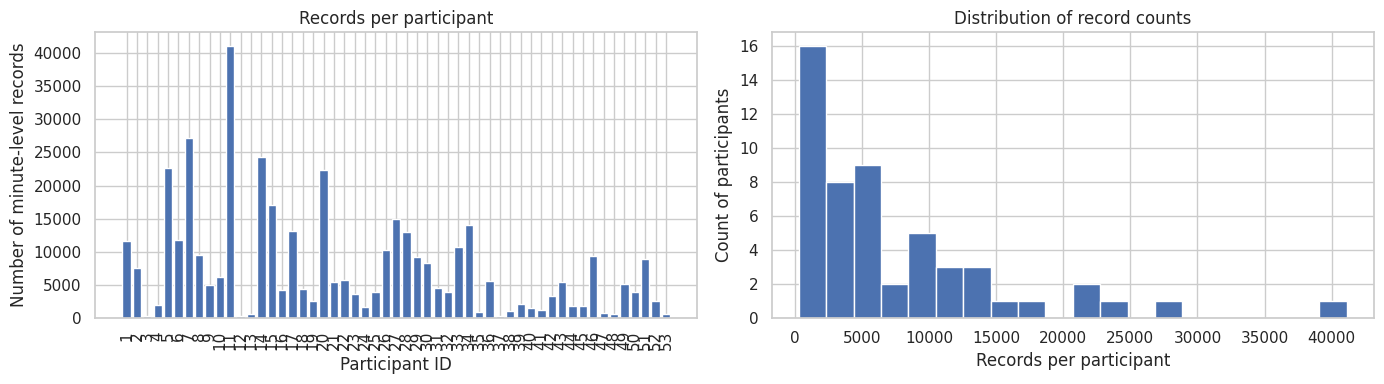

In [8]:
counts = df['ID'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(counts.index.astype(str), counts.values)
axes[0].set_xlabel('Participant ID')
axes[0].set_ylabel('Number of minute-level records')
axes[0].set_title('Records per participant')
axes[0].tick_params(axis='x', rotation=90)

axes[1].hist(counts.values, bins=20, edgecolor='white')
axes[1].set_xlabel('Records per participant')
axes[1].set_ylabel('Count of participants')
axes[1].set_title('Distribution of record counts')

plt.tight_layout()
plt.show()

In [9]:
# Some participants have significantly more samples than others. When doing per participant splitting try to balance
# the total numbers of samples across splits besides the number of participants.

### Feature Distributions

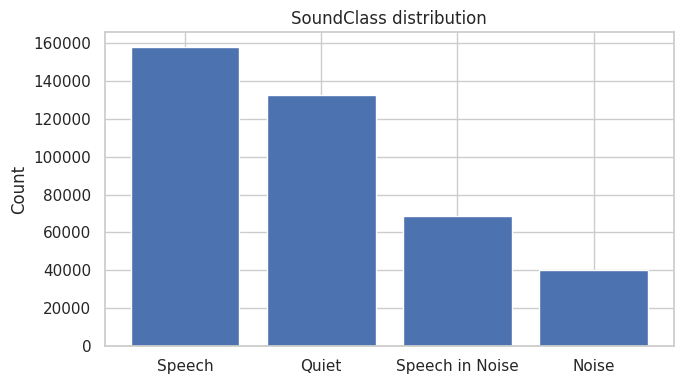

In [10]:
# Target variable for Task 1 : SoundClass (4 categories)
fig, ax = plt.subplots(figsize=(7, 4))
vc = df['SoundClass'].value_counts()
ax.bar(vc.index, vc.values)
ax.set_title('SoundClass distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [11]:
# There is some class imbalance.

In [12]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print('Numeric columns:', numeric_cols)

Numeric columns: ['ID', 'hVol', 'LonRel', 'LatRel', 'lowSPL', 'midSPL', 'highSPL', 'fbSPL', 'lowNf', 'midNf', 'highNf', 'fbNf', 'lowME', 'midME', 'highME', 'fbME', 'lowSNR', 'midSNR', 'highSNR', 'fbSNR', 'lowMI', 'midMI', 'highMI', 'fbMI', 'PTA4']


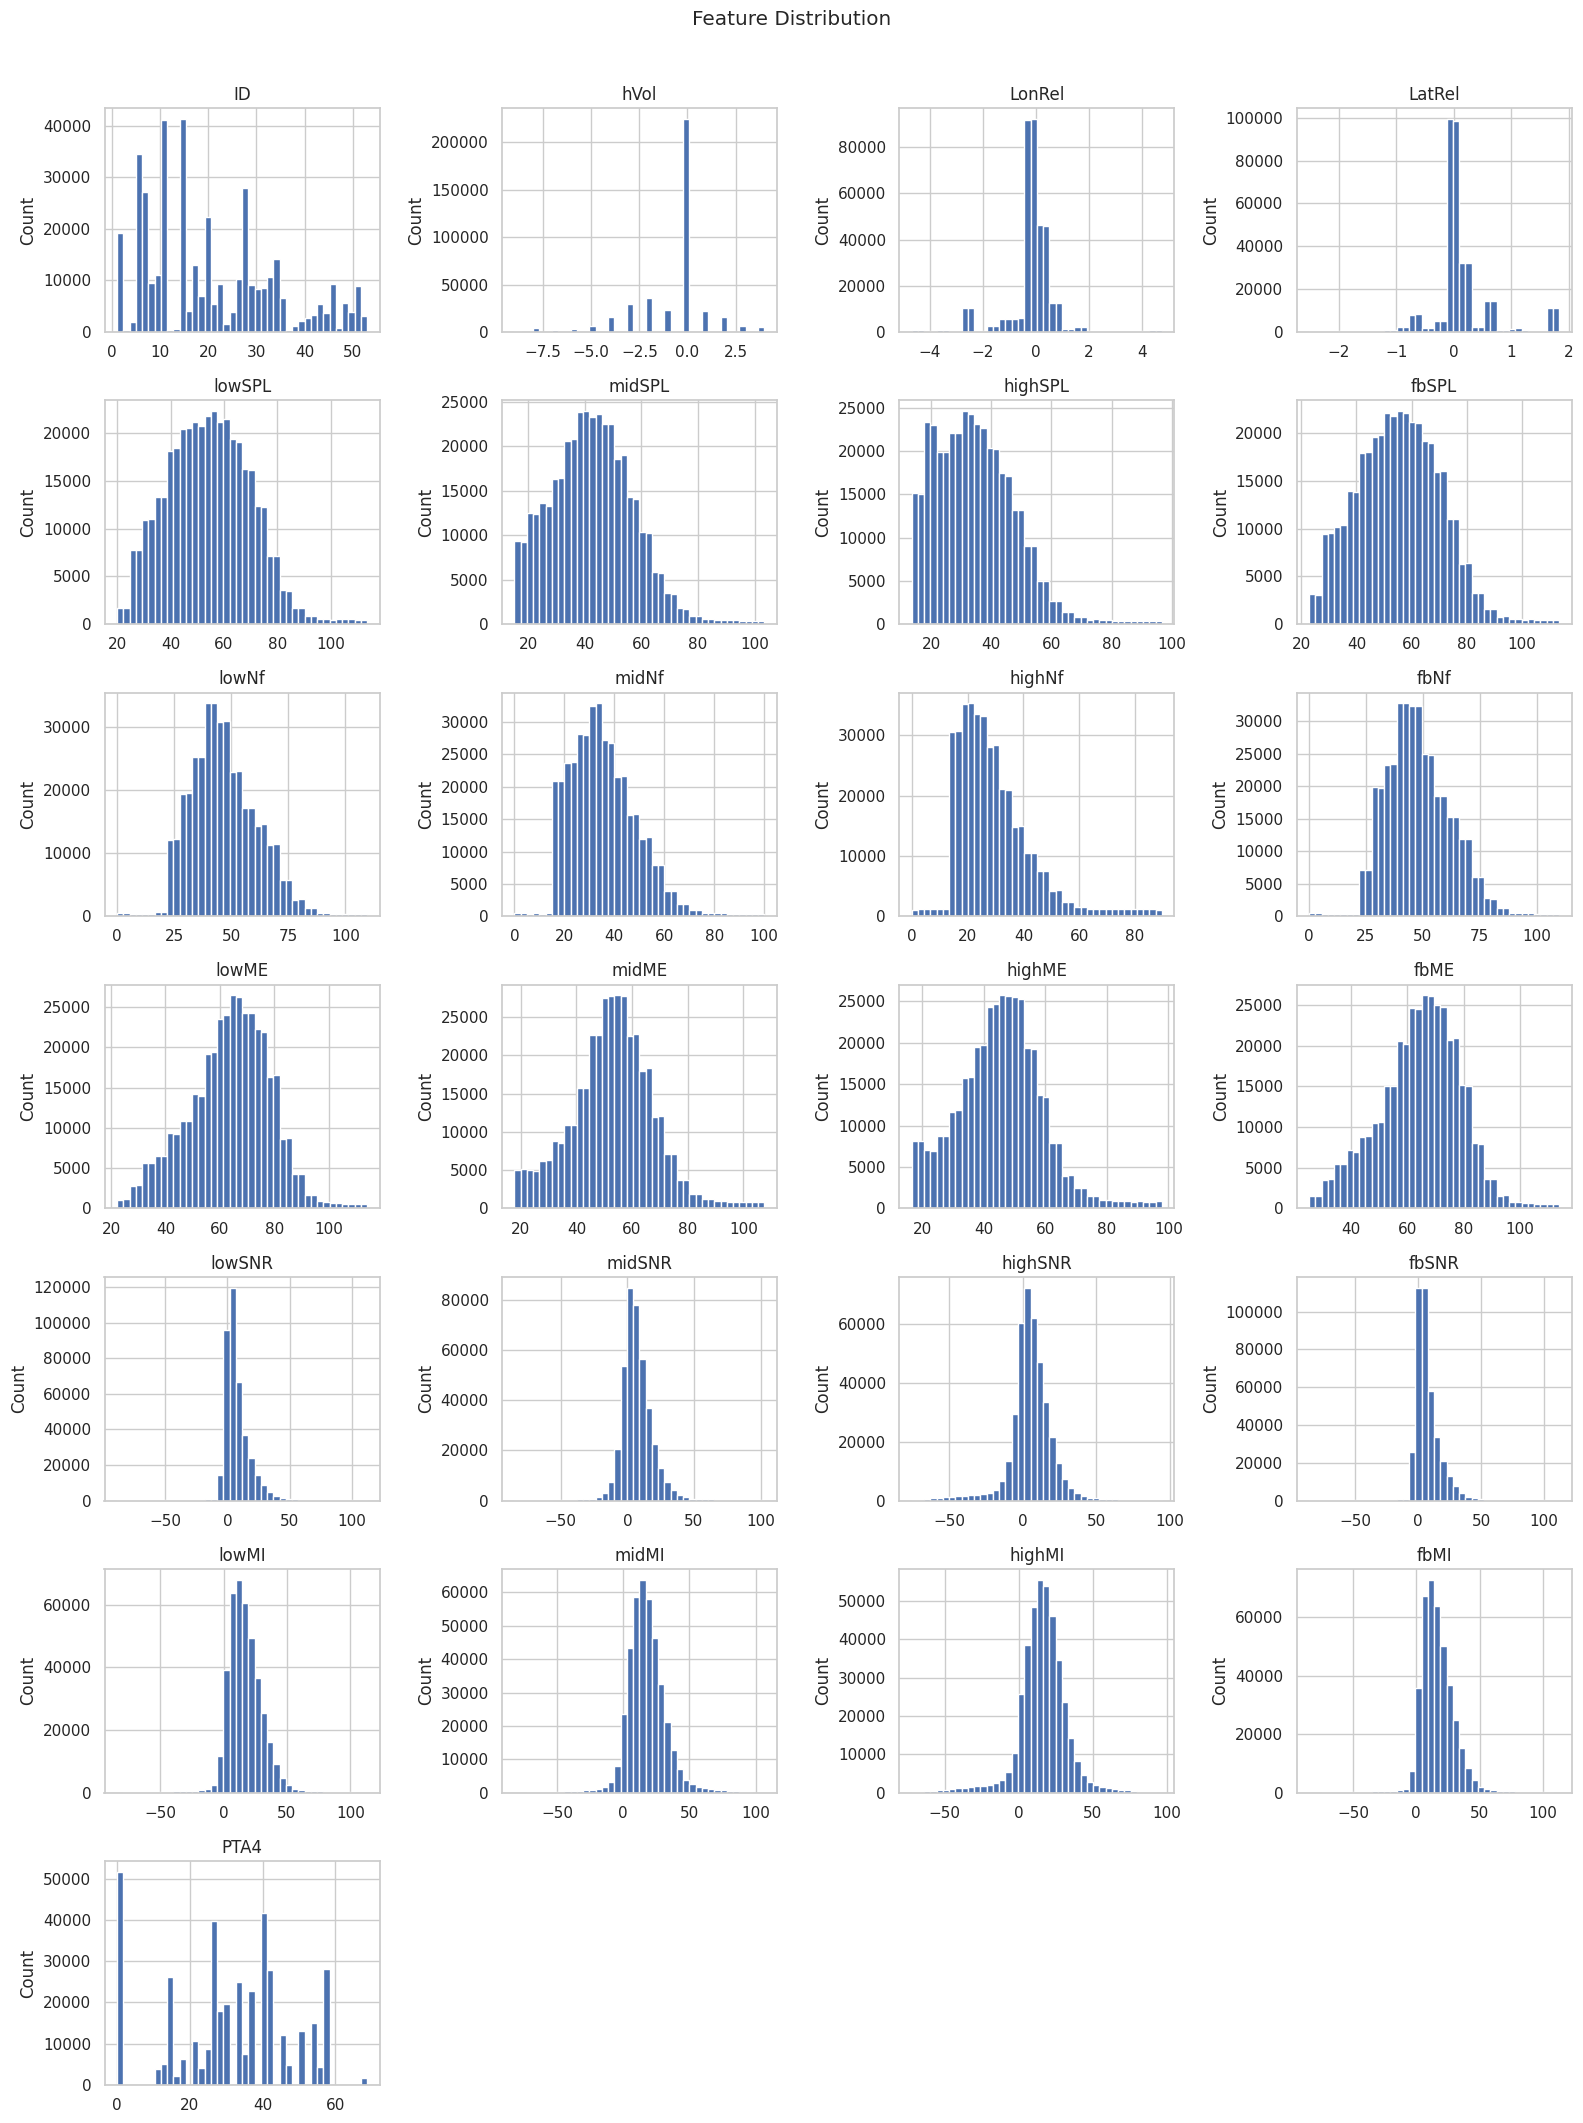

In [13]:
n = len(numeric_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=40, edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distribution', y=1.01) # numerical ones
plt.tight_layout()
plt.show()

In [14]:
# To consider: skewness, outliers, scale differences, variation/constant ..

### hVol Missingness Analysis

In [ ]:
# hVol [-9, 4] represents the hearing aid volume adjustment relative to the device default. 
# A value of 0 means the participant is currently at the default volume.
# A missing value means the device did not log a volume change at that minute (makes sense that users do not adjust the volume constantly)
# Between adjustments lets use the last setting applied -> LOCF (Last Observation Carried Forward) for imputation

In [4]:
from pathlib import Path

# Path to subject files
subjects_dir = Path('data/subjects')

records = []
# Iterate over all subjects
for f in sorted(subjects_dir.glob('subject_*.csv')):
    subject = pd.read_csv(f, parse_dates=['Timestamp'])
    subject_id = int(f.stem.split('_')[1])
    total_samples = len(subject) # number of samples per subject
    missing_samples = subject['hVol'].isnull().sum() # hVol missing values
    records.append({'ID': subject_id, 'missing': missing_samples, 'total': total_samples, 'percentage': round(missing_samples / total_samples * 100, 2)})

missing_df = pd.DataFrame(records).set_index('ID').sort_index()

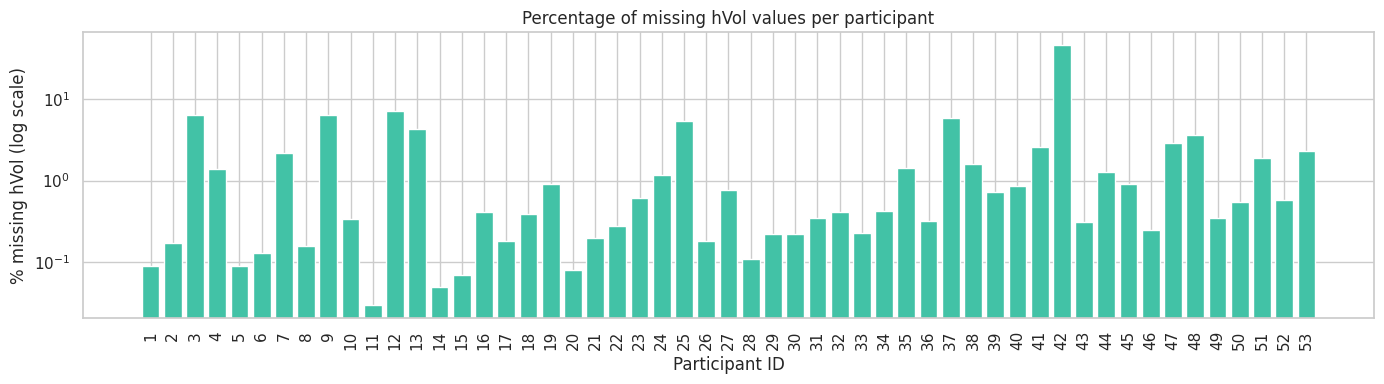

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#42C2A6' if v > 0 else 'lightgray' for v in missing_df['percentage']]
ax.bar(missing_df.index.astype(str), missing_df['percentage'], color=colors)
ax.set_xlabel('Participant ID')
ax.set_ylabel('% missing hVol (log scale)')
ax.set_title('Percentage of missing hVol values per participant')
ax.set_yscale('log')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

### PTA4 Distribution Analysis

In [6]:
# One PTA4 value per participant (constant across all rows for the same participant)
pta4 = df[['ID', 'PTA4']].drop_duplicates('ID').set_index('ID')['PTA4'].sort_index()

print("PTA4 summary statistics across 53 participants:")
print(f"Mean: {pta4.mean():.2f} dB")
print(f"Std: {pta4.std():.2f} dB")
print(f"Min: {pta4.min():.2f} dB")
print(f"Max: {pta4.max():.2f} dB")
print(f"25th percentile: {pta4.quantile(0.25):.2f} dB")
print(f" Median: {pta4.median():.2f} dB")
print(f" 75th percentile: {pta4.quantile(0.75):.2f} dB")

PTA4 summary statistics across 53 participants:
Mean: 28.94 dB
Std: 17.52 dB
Min: 0.00 dB
Max: 68.75 dB
25th percentile: 16.25 dB
 Median: 28.75 dB
 75th percentile: 41.25 dB


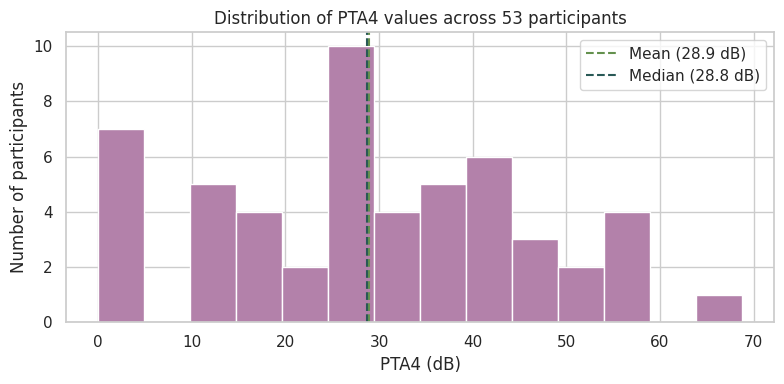

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pta4.values, bins=14, edgecolor='white', color='#B381AA')
ax.axvline(pta4.mean(), color='#64914E', linestyle='--', label=f'Mean ({pta4.mean():.1f} dB)')
ax.axvline(pta4.median(), color='#295956', linestyle='--', label=f'Median ({pta4.median():.1f} dB)')
ax.set_xlabel('PTA4 (dB)')
ax.set_ylabel('Number of participants')
ax.set_title('Distribution of PTA4 values across 53 participants')
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Data covers different hearing loss levels.

### Weekly Coverage Analysis

In [11]:
daily = pd.read_csv('data/daily_features.csv', parse_dates=['date'])

study_start = daily['date'].min()
daily['week'] = ((daily['date'] - study_start).dt.days // 7) + 1

weekly = daily.groupby(['ID', 'week'])[['wear_time_minutes', 'hProg_proportion_low', 'hVol_mean']].mean().reset_index()

all_ids = sorted(weekly['ID'].unique())
all_weeks = list(range(1, daily['week'].max() + 1))

coverage = weekly.groupby(['ID', 'week']).size().unstack(fill_value=0).reindex(index=all_ids, columns=all_weeks, fill_value=0)
coverage = (coverage > 0).astype(int)

print(f"Study covers {daily['week'].max()} weeks\n")
for pid in all_ids:
    missing = [w for w in all_weeks if coverage.loc[pid, w] == 0]
    if missing:
        print(f"Participant {pid}: {len(missing)} missing | position {missing}")

Study covers 18 weeks

Participant 4: 1 missing | position [18]
Participant 6: 1 missing | position [18]
Participant 13: 1 missing | position [18]
Participant 21: 1 missing | position [18]
Participant 36: 1 missing | position [18]


In [ ]:
# Only participants 4, 13, 21, 6 and 26 have missing weeks and it's always the last week (recording ended one week ealier). 